In [72]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import functions_spin_p as fy
from importlib import reload

reload(fy)

<module 'functions_spin_p' from '/mnt/c/Users/frnkl/Desktop/thesis_spin_caloritronics/tesis_models/horizontal_model/functions_spin_p.py'>

In [73]:
import spin_thermoelectric_coefficients as th
reload(th)

<module 'spin_thermoelectric_coefficients' from '/mnt/c/Users/frnkl/Desktop/thesis_spin_caloritronics/tesis_models/horizontal_model/spin_thermoelectric_coefficients.py'>

In [74]:
#Parameters

energy_axis = np.arange(-6, 6 + 0.01, 0.01) #meV
print("Energy axis is", energy_axis,"meV")

#Gamma i.e. width parameter
gamma = 0.5 #meV
print("The width is:",gamma,"meV")

#Site energies:
e_1 = 0 #meV
e_2 = 0 #meV

print("The site (spin independent) energies are:", \
      e_1," meV and",e_2," meV")

Energy axis is [-6.   -5.99 -5.98 ...  5.98  5.99  6.  ] meV
The width is: 0.5 meV
The site (spin independent) energies are: 0  meV and 0  meV


In [75]:
#More Parameters
temperature = 3 #Kelvin
print("T is:", temperature,"Kelvin")

fermi_axis = np.arange(-6, 6 + 0.01, 0.01) #meV
print("Fermi Energy axis is", fermi_axis,"meV")

T is: 3 Kelvin
Fermi Energy axis is [-6.   -5.99 -5.98 ...  5.98  5.99  6.  ] meV


In [76]:
#Define the \Delta parameter previously the definition of the Hamiltonian 

delta = 0 #meV

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 
#v = 3

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

print(Hamiltonian)

[[0.+0.j 0.+0.j 2.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 2.+0.j]
 [2.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 2.+0.j 0.+0.j 0.+0.j]]


In [77]:
#POLARIZATION UP-UP
p_L_1 = 1
p_R_1 = 0

#Transmission axis

transmission_u_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, p_L_1, p_R_1)[0]
transmission_d_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, p_L_1, p_R_1)[1]

#Thermopower
seebeck_1 = th.S(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian)
seebeck_u_1 = th.S_up(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian)
seebeck_d_1 = th.S_down(fermi_axis, temperature, energy_axis, p_L_1, p_R_1, gamma, Hamiltonian)

In [78]:
#POLARIZATION UP-DOWN
p_L_2 = -1
p_R_2 = 0

#Transmission axis

transmission_u_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, p_L_2, p_R_2)[0]
transmission_d_2 = fy.Transmission(energy_axis, gamma, Hamiltonian, p_L_2, p_R_2)[1]

#Thermopower
seebeck_2 = th.S(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian)
seebeck_u_2 = th.S_up(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian)
seebeck_d_2 = th.S_down(fermi_axis, temperature, energy_axis, p_L_2, p_R_2, gamma, Hamiltonian)

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:58: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


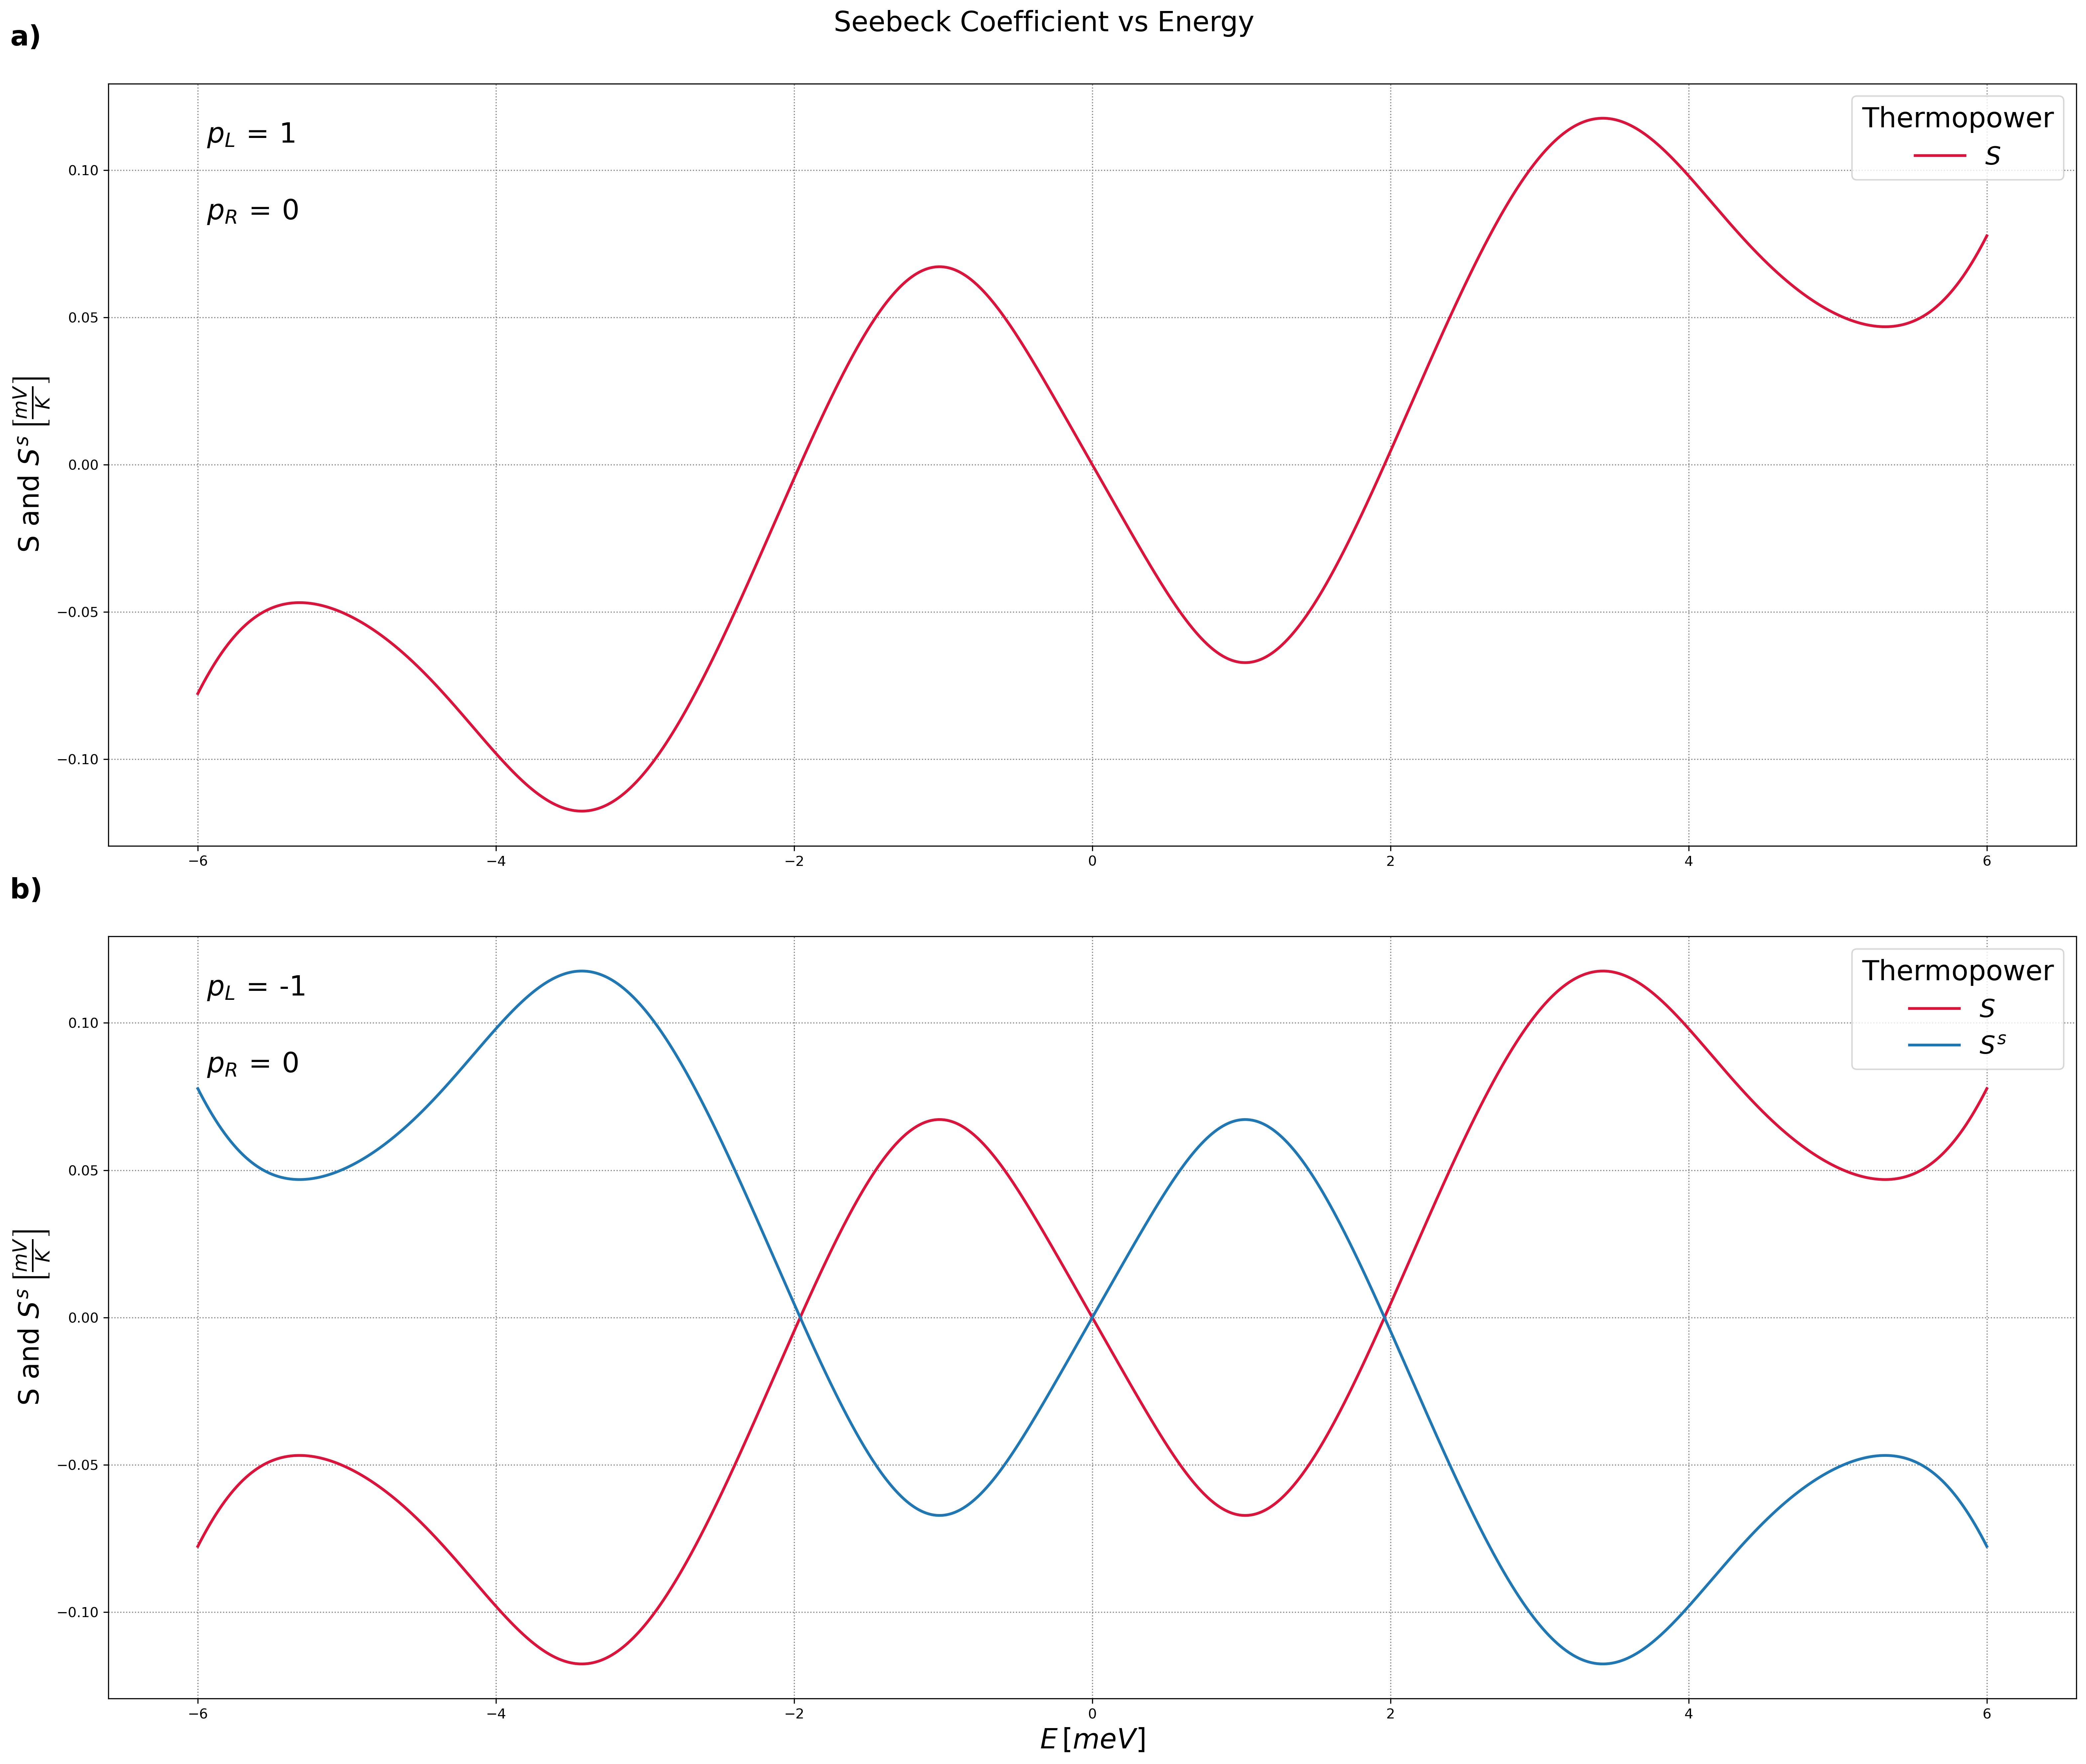

In [79]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(21, 18), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

# Set the grid for the subplots
gs = GridSpec(2, 1, figure=fig)

# Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])

ax1.grid(linestyle=':', color='grey')
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_1 + seebeck_d_1), "#DC143C", label=r"$S$", linestyle="-", lw =2)
#ax1.plot(fermi_axis, -(1/2)*(seebeck_u_1 - seebeck_d_1), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw =2)
#ax1.set_xlabel(r'$\mu\,[meV]$', fontsize=20)
ax1.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=20)
ax1.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_1), transform=ax1.transAxes, fontsize=20,
         verticalalignment='top', bbox=props)
ax1.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_1), transform=ax1.transAxes, fontsize=20,
         verticalalignment='top', bbox=props)
ax1.legend(
    fontsize=18,
    title="Thermopower",
    title_fontsize=20,
    loc="upper right"
)
# Etiqueta a)
ax1.text(-0.05, 1.05, 'a)', transform=ax1.transAxes, fontsize=20, fontweight='bold')

ax2.grid(linestyle=':', color='grey')
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_2 + seebeck_d_2), "#DC143C", label=r"$S$", linestyle="-", lw = 2)
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_2 - seebeck_d_2), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw = 2)
ax2.set_xlabel(r'$E\,[meV]$', fontsize=20)
ax2.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=20)
ax2.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_2), transform=ax2.transAxes, fontsize=20,
         verticalalignment='top', bbox=props)
ax2.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_2), transform=ax2.transAxes, fontsize=20,
         verticalalignment='top', bbox=props)
ax2.legend(
    fontsize=18,
    title="Thermopower",
    title_fontsize=20,
    loc="upper right"
)
# Etiqueta b)
ax2.text(-0.05, 1.05, 'b)', transform=ax2.transAxes, fontsize=20, fontweight='bold')

# Stablish limits for the subplots
#ax1.set_xlim(-6, 6)  
#ax1.set_ylim(-0.2, 0.2)
#ax2.set_xlim(-6, 6)
#ax2.set_ylim(-0.2, 0.2)

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Seebeck Coefficient vs Energy", fontsize=20)
plt.tight_layout()
plt.show()
#fig.savefig('thermopower_geyer.jpg')


In [80]:
# Definir la función sigmoide para suavizar el corte
def sigmoid_cutoff(values, energy, cutoff=4, width=0.5):
    factor = 1 / (1 + np.exp((np.abs(energy) - cutoff) / width))
    return values * factor


In [81]:
# Aplicar cutoff suave a seebeck_1, seebeck_u_1 y seebeck_d_1
seebeck_1 = sigmoid_cutoff(seebeck_1, fermi_axis)
seebeck_u_1 = sigmoid_cutoff(seebeck_u_1, fermi_axis)
seebeck_d_1 = sigmoid_cutoff(seebeck_d_1, fermi_axis)

# Aplicar cutoff suave a seebeck_2, seebeck_u_2 y seebeck_d_2
seebeck_2 = sigmoid_cutoff(seebeck_2, fermi_axis)
seebeck_u_2 = sigmoid_cutoff(seebeck_u_2, fermi_axis)
seebeck_d_2 = sigmoid_cutoff(seebeck_d_2, fermi_axis)


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:58: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


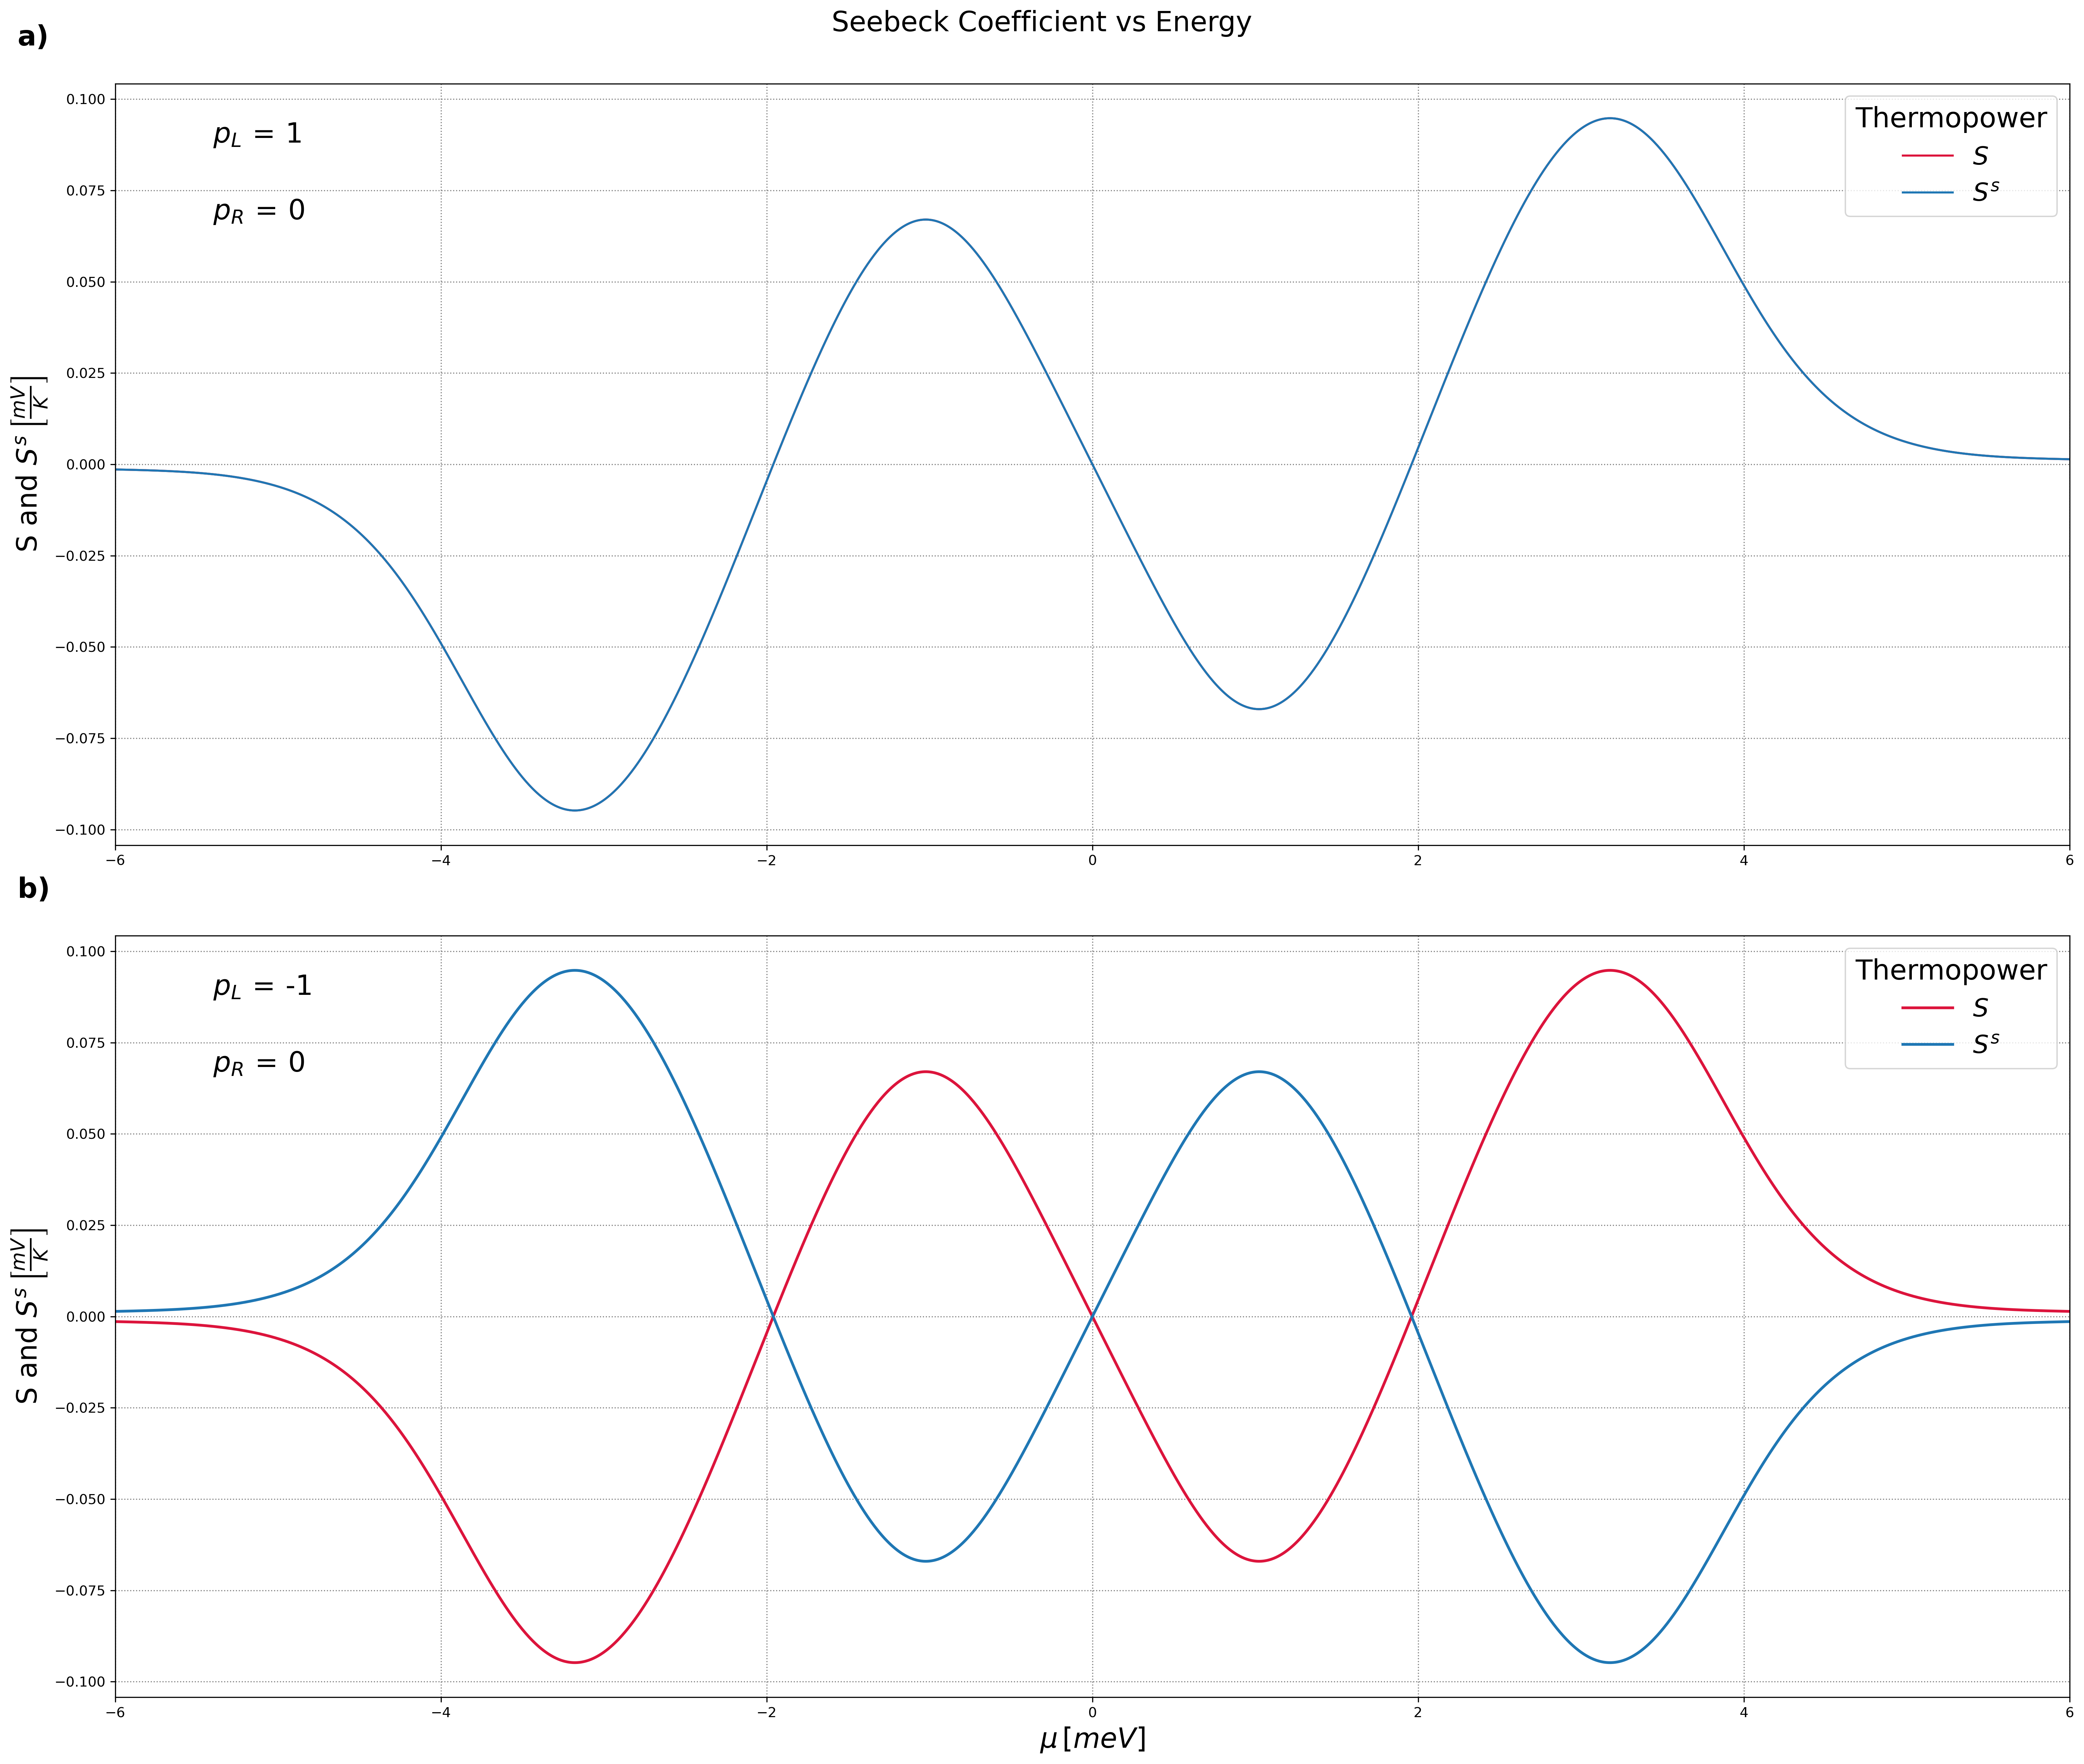

In [82]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(21, 18), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

# Set the grid for the subplots
gs = GridSpec(2, 1, figure=fig)

# Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])

ax1.grid(linestyle=':', color='grey')
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_1 + seebeck_d_1), "#DC143C", label=r"$S$", linestyle="-")
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_1 - seebeck_d_1), "#1f77b4", label=r"$S^{s}$", linestyle="-")
#ax1.set_xlabel(r'$\mu\,[meV]$', fontsize=20)
ax1.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=20)
ax1.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_1), transform=ax1.transAxes, fontsize=20,
         verticalalignment='top', bbox=props)
ax1.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_1), transform=ax1.transAxes, fontsize=20,
         verticalalignment='top', bbox=props)
ax1.legend(
    fontsize=18,
    title="Thermopower",
    title_fontsize=20,
    loc="upper right"
)
# Etiqueta a)
ax1.text(-0.05, 1.05, 'a)', transform=ax1.transAxes, fontsize=20, fontweight='bold')

ax2.grid(linestyle=':', color='grey')
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_2 + seebeck_d_2), "#DC143C", label=r"$S$", linestyle="-", lw = 2)
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_2 - seebeck_d_2), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw = 2)
ax2.set_xlabel(r'$\mu\,[meV]$', fontsize=20)
ax2.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=20)
ax2.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_2), transform=ax2.transAxes, fontsize=20,
         verticalalignment='top', bbox=props)
ax2.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_2), transform=ax2.transAxes, fontsize=20,
         verticalalignment='top', bbox=props)
ax2.legend(
    fontsize=18,
    title="Thermopower",
    title_fontsize=20,
    loc="upper right"
)
# Etiqueta b)
ax2.text(-0.05, 1.05, 'b)', transform=ax2.transAxes, fontsize=20, fontweight='bold')

# Stablish limits for the subplots
ax1.set_xlim(-6, 6)
#ax1.set_ylim(-0.2, 0.2)
ax2.set_xlim(-6, 6)
#ax2.set_ylim(-0.2, 0.2)

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Seebeck Coefficient vs Energy", fontsize=20)
plt.tight_layout()
plt.show()
#fig.savefig('thermopower_geyer_masked.jpg')

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:66: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


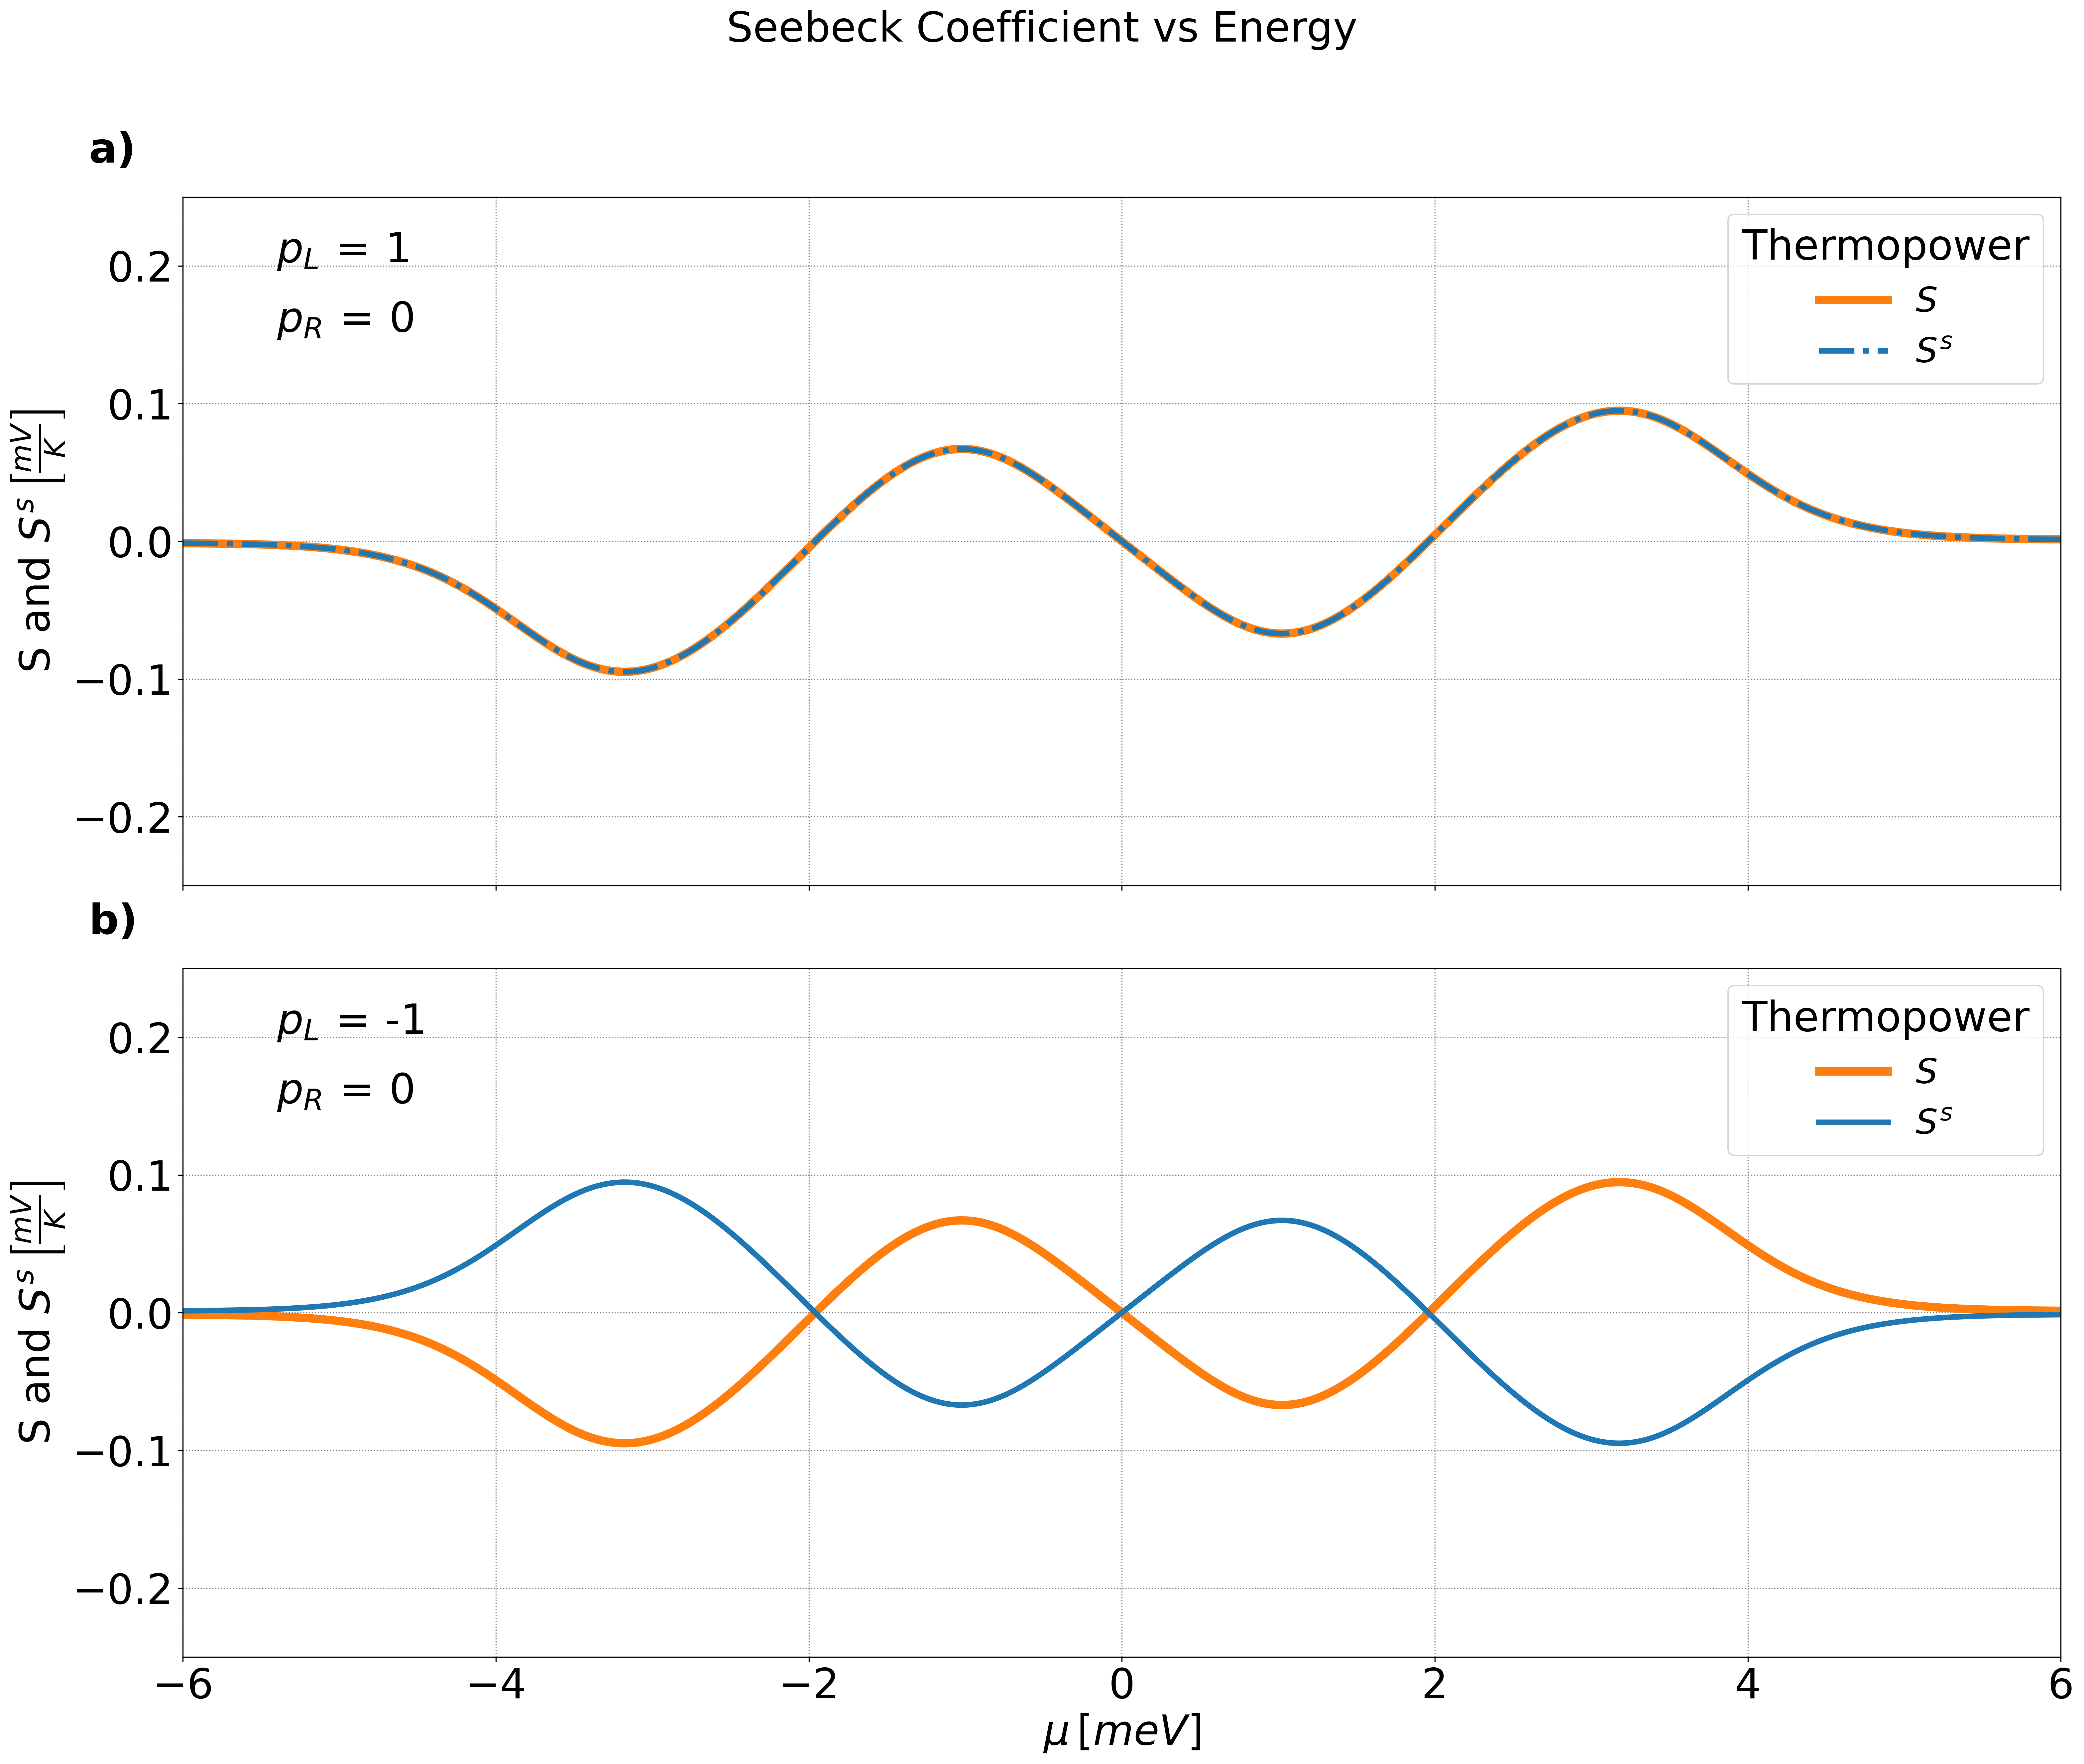

In [83]:
# Crear la figura y los ejes
fig = plt.figure(constrained_layout=True, figsize=(21, 18), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

# Set the grid for the subplots
gs = GridSpec(2, 1, figure=fig)

# Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])

ax1.grid(linestyle=':', color='grey')
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_1 + seebeck_d_1), "#ff7f0e", label=r"$S$", linestyle="-", lw=6)
ax1.plot(fermi_axis, -(1/2)*(seebeck_u_1 - seebeck_d_1), "#1f77b4", label=r"$S^{s}$", linestyle="-.", lw=4)
ax1.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=30)
ax1.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_1), transform=ax1.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax1.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_1), transform=ax1.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax1.legend(
    fontsize=25,
    title="Thermopower",
    title_fontsize=30,
    loc="upper right"
)
# Etiqueta a)
ax1.text(-0.05, 1.05, 'a)', transform=ax1.transAxes, fontsize=30, fontweight='bold')

ax2.grid(linestyle=':', color='grey')
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_2 + seebeck_d_2), "#ff7f0e", label=r"$S$", linestyle="-", lw=6)
ax2.plot(fermi_axis, -(1/2)*(seebeck_u_2 - seebeck_d_2), "#1f77b4", label=r"$S^{s}$", linestyle="-", lw=4)
ax2.set_xlabel(r'$\mu\,[meV]$', fontsize=30)
ax2.set_ylabel(r'S and $S^{s}\,\left[\frac{mV}{K} \right]$', fontsize=30)
ax2.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L_2), transform=ax2.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax2.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R_2), transform=ax2.transAxes, fontsize=30,
         verticalalignment='top', bbox=props)
ax2.legend(
    fontsize=25,
    title="Thermopower",
    title_fontsize=30,
    loc="upper right"
)
# Etiqueta b)
ax2.text(-0.05, 1.05, 'b)', transform=ax2.transAxes, fontsize=30, fontweight='bold')

# Establecer límites para los subplots
ax1.set_xlim(-6, 6)
ax1.set_ylim(-0.25, 0.25)
ax2.set_xlim(-6, 6)
ax2.set_ylim(-0.25, 0.25)

# Ajustar el tamaño de las etiquetas de los ejes x e y
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax2.tick_params(axis='x', labelsize=30)
ax2.tick_params(axis='y', labelsize=30)

# Eliminar los números del eje x en el primer subplot
ax1.set_xticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Seebeck Coefficient vs Energy", fontsize=30)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Guardar la imagen
#fig.savefig('thermopower_geyer_masked.jpg', bbox_inches='tight')
